# CIFAR-10 Image Classification: ANN vs CNN

This notebook builds, trains, and rigorously compares three models on CIFAR-10:
1. **ANN (Artificial Neural Network)** - a fully-connected baseline
2. **CNN (Convolutional Neural Network)** - a spatial-feature-aware model
3. **Augmented CNN** - the same CNN trained with on-the-fly data augmentation + EarlyStopping

##  1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


##  2. Load Dataset
CIFAR-10 downloads automatically the first time via `tf.keras.datasets.cifar10`.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", x_train.shape, "| Train labels:", y_train.shape)
print("Test shape: ", x_test.shape, "| Test labels: ", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5004s 29us/step
Train shape: (50000, 32, 32, 3) | Train labels: (50000,)
Test shape:  (10000, 32, 32, 3) | Test labels:  (10000,)


##  3. Visualize Sample Images

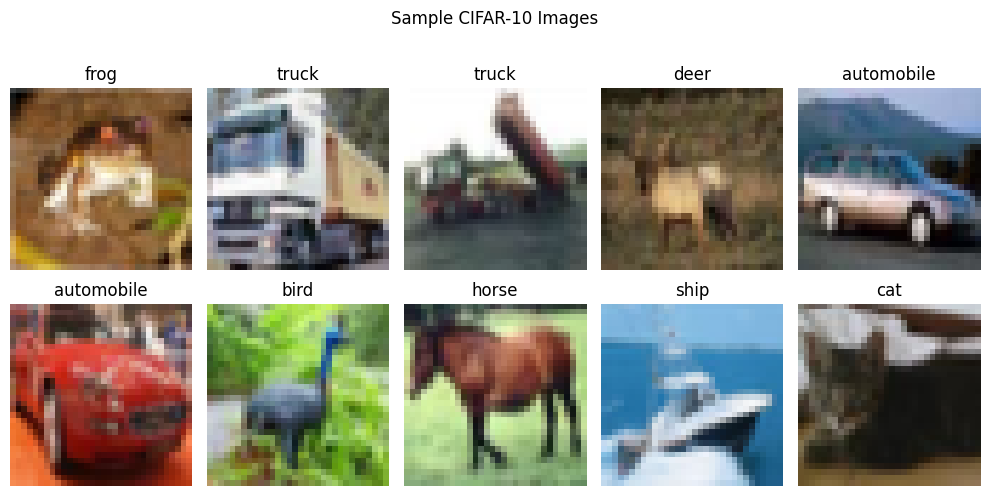

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images", y=1.02)
plt.tight_layout()
plt.show()

### Class distribution (sanity check  CIFAR-10 is perfectly balanced)

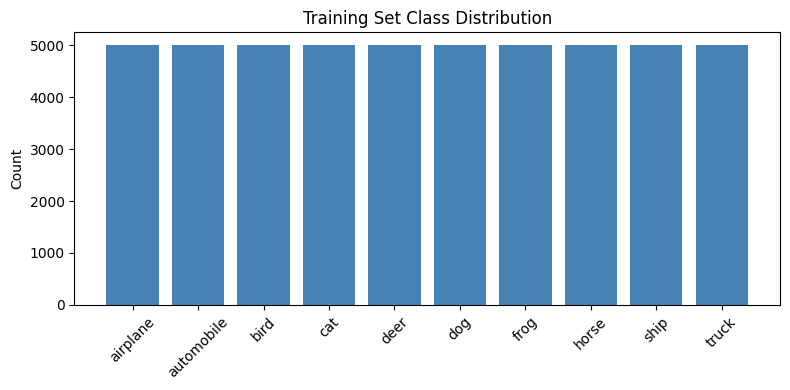

In [4]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue')
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Training Set Class Distribution")
plt.tight_layout()
plt.show()

##  4. Preprocessing
- Normalize pixels from **0–255 → 0–1** for stable gradients
- Keep an image-shaped version `(32,32,3)` for the CNN
- Keep a flattened version `(3072,)` for the ANN

In [5]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened ANN input shape:", x_train_flat.shape)
print("Image-shaped CNN input shape:", x_train_norm.shape)

Flattened ANN input shape: (50000, 3072)
Image-shaped CNN input shape: (50000, 32, 32, 3)


##  5. Part 1 - ANN Model
An ANN treats the image as a flat vector of 3,072 numbers, so it has **no notion of which
pixels are spatially close**. This is the key limitation we'll see reflected in its accuracy.

In [6]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
ann_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=128,
    callbacks=[ann_early_stop],
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.2542 - loss: 2.0227 - val_accuracy: 0.3218 - val_loss: 1.9034
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3101 - loss: 1.8880 - val_accuracy: 0.3614 - val_loss: 1.7906
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3304 - loss: 1.8363 - val_accuracy: 0.3754 - val_loss: 1.7850
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3453 - loss: 1.7984 - val_accuracy: 0.3874 - val_loss: 1.7475
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3550 - loss: 1.7765 - val_accuracy: 0.3910 - val_loss: 1.7167
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3661 - loss: 1.7528 - val_accuracy: 0.3994 - val_loss: 1.7083
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3693 - loss: 1.7349 - val_accuracy: 0.3928 - val_loss: 1.7133
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3713 - loss: 1.7241 - val_acc

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"ANN Test Loss:     {ann_test_loss:.4f}")

ANN Test Accuracy: 0.4489
ANN Test Loss:     1.5694


##  6. Part 2 - CNN Model
CNNs preserve spatial structure through:
- **Convolutions** - learn local feature detectors (edges → textures → shapes)
- **Pooling** - downsample while keeping the strongest signals
- **Batch Normalization** - stabilizes and speeds up training
- **Dropout** - reduces overfitting

This is why CNNs dramatically outperform ANNs on image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
cnn_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=25,
    validation_split=0.1,
    batch_size=64,
    callbacks=[cnn_early_stop],
    verbose=1
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 118ms/step - accuracy: 0.3533 - loss: 1.7606 - val_accuracy: 0.4448 - val_loss: 1.6337
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5082 - loss: 1.3695 - val_accuracy: 0.6044 - val_loss: 1.0980
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5882 - loss: 1.1670 - val_accuracy: 0.5676 - val_loss: 1.3795
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.6428 - loss: 1.0263 - val_accuracy: 0.6836 - val_loss: 0.8973
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 115ms/step - accuracy: 0.6757 - loss: 0.9326 - val_accuracy: 0.7330 - val_loss: 0.7790
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7018 - loss: 0.8697 - val_accuracy: 0.7038 - val_loss: 0.8996
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7212 - loss: 0.8102 - val_accuracy: 0.7604 - val_loss: 0.6846
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 141ms/step - accuracy: 0.7394 - loss:

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss:     {cnn_test_loss:.4f}")

CNN Test Accuracy: 0.8299
CNN Test Loss:     0.5369


##  7. Compare Learning Curves - ANN vs CNN

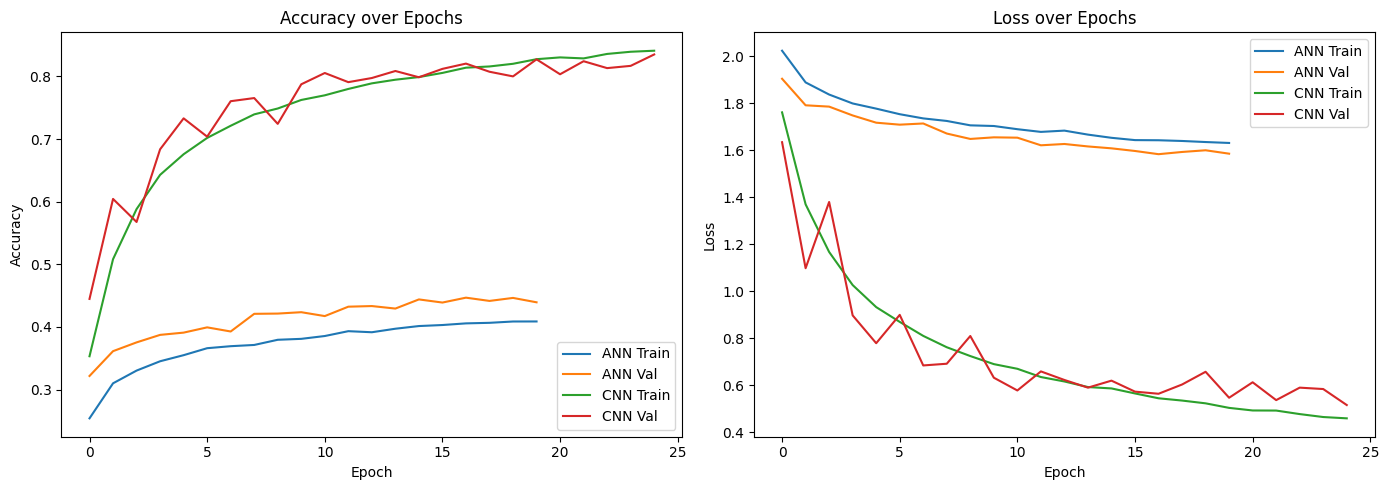

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['accuracy'], label='ANN Train')
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val')
axes[0].plot(cnn_history.history['accuracy'], label='CNN Train')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(ann_history.history['loss'], label='ANN Train')
axes[1].plot(ann_history.history['val_loss'], label='ANN Val')
axes[1].plot(cnn_history.history['loss'], label='CNN Train')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

##  8. Training Strategy Upgrade - Data Augmentation
Data augmentation generates randomly transformed versions of training images
(flips, rotations, zooms) every epoch, which reduces overfitting and improves
generalization to unseen images - without collecting more data.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=6, restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 158ms/step - accuracy: 0.3039 - loss: 1.9148 - val_accuracy: 0.4288 - val_loss: 1.5426
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.3985 - loss: 1.6299 - val_accuracy: 0.4366 - val_loss: 1.7349
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.4568 - loss: 1.4913 - val_accuracy: 0.4936 - val_loss: 1.4437
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.5020 - loss: 1.3915 - val_accuracy: 0.5044 - val_loss: 1.6863
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 158ms/step - accuracy: 0.5345 - loss: 1.3100 - val_accuracy: 0.5550 - val_loss: 1.4199
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.5678 - loss: 1.2352 - val_accuracy: 0.6008 - val_loss: 1.1896
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.5922 - loss: 1.1716 - val_accuracy: 0.5844 - val_loss: 1.3992
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.6065 -

In [14]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}")
print(f"Augmented CNN Test Loss:     {aug_test_loss:.4f}")

Augmented CNN Test Accuracy: 0.7558
Augmented CNN Test Loss:     0.7352


### Learning curves - plain CNN vs augmented CNN

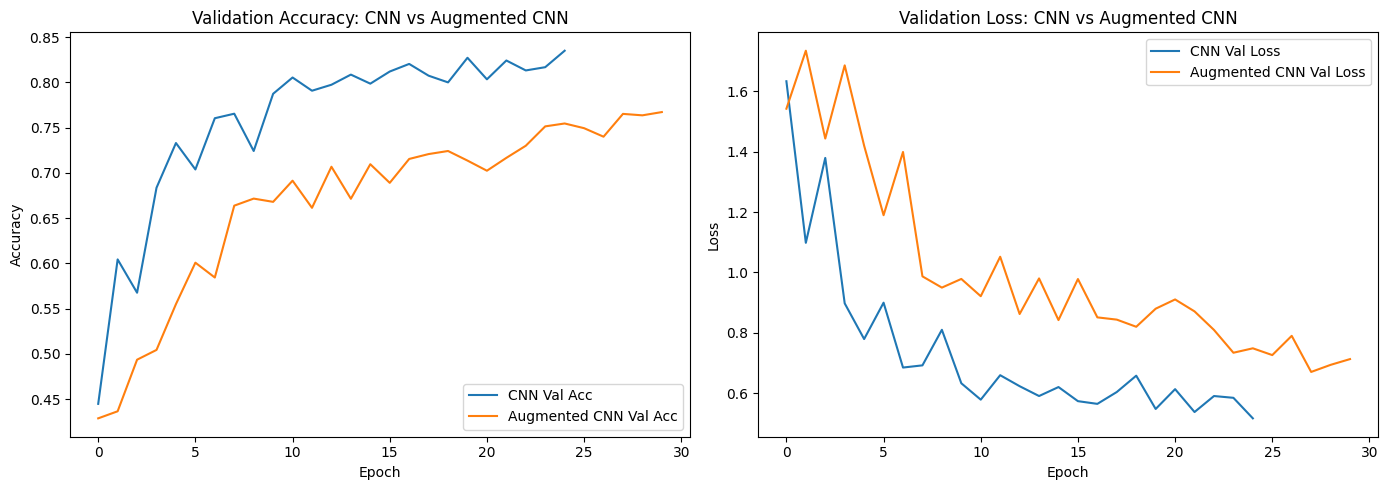

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
axes[0].plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
axes[0].set_title("Validation Accuracy: CNN vs Augmented CNN")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss')
axes[1].plot(aug_history.history['val_loss'], label='Augmented CNN Val Loss')
axes[1].set_title("Validation Loss: CNN vs Augmented CNN")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

##  9. Deeper Evaluation - Confusion Matrix & Classification Report
Overall accuracy hides *which* classes get confused with each other (e.g. cats vs dogs,
automobiles vs trucks). A confusion matrix makes this explicit.

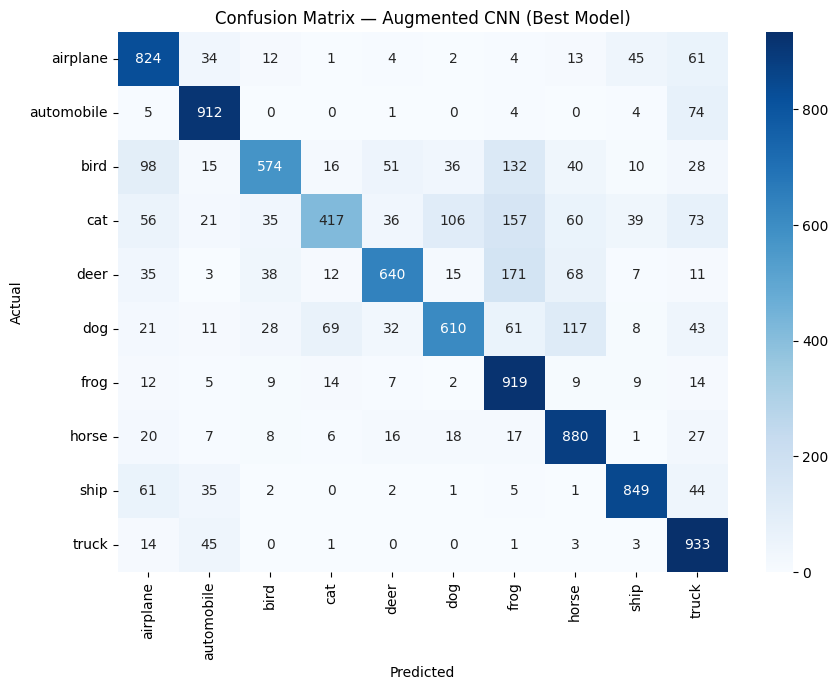

In [16]:
y_pred_probs = aug_cnn_model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Augmented CNN (Best Model)")
plt.tight_layout()
plt.show()

In [17]:
print("Classification Report — Augmented CNN\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report — Augmented CNN

              precision    recall  f1-score   support

    airplane       0.72      0.82      0.77      1000
  automobile       0.84      0.91      0.87      1000
        bird       0.81      0.57      0.67      1000
         cat       0.78      0.42      0.54      1000
        deer       0.81      0.64      0.72      1000
         dog       0.77      0.61      0.68      1000
        frog       0.62      0.92      0.74      1000
       horse       0.74      0.88      0.80      1000
        ship       0.87      0.85      0.86      1000
       truck       0.71      0.93      0.81      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.75     10000
weighted avg       0.77      0.76      0.75     10000



### Inspect a few misclassified images

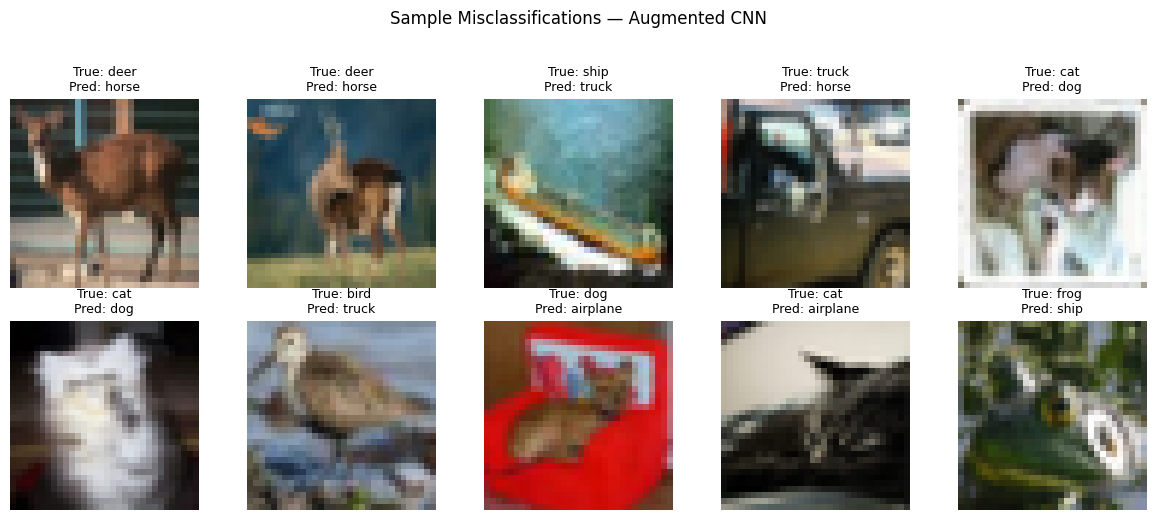

In [18]:
wrong_idx = np.where(y_pred != y_test)[0]
sample_wrong = np.random.choice(wrong_idx, size=10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_wrong):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Misclassifications — Augmented CNN", y=1.03)
plt.tight_layout()
plt.show()

##  10. Final Comparison Table

In [19]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss],
    "Trainable Params": [
        ann_model.count_params(),
        cnn_model.count_params(),
        aug_cnn_model.count_params()
    ]
})
comparison["Test Accuracy"] = comparison["Test Accuracy"].round(4)
comparison["Test Loss"] = comparison["Test Loss"].round(4)
comparison

,Model,Test Accuracy,Test Loss,Trainable Params
0,ANN,0.4489,1.5694,1738890
1,CNN,0.8299,0.5369,403882
2,Augmented CNN,0.7558,0.7352,403882


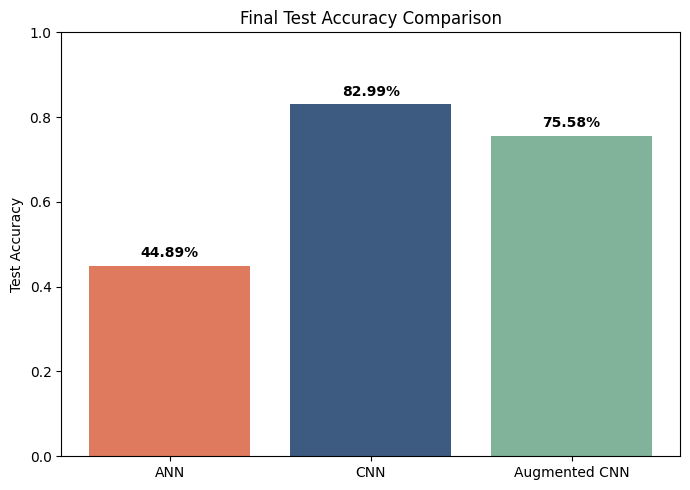

In [20]:
plt.figure(figsize=(7, 5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"],
                color=['#e07a5f', '#3d5a80', '#81b29a'])
plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy Comparison")
plt.ylim(0, 1)
for bar, acc in zip(bars, comparison["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.2%}",
              ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## ✅ 12. Conclusion
- **ANN** treats every pixel independently - it ignores spatial structure, so it plateaus at a
  noticeably lower accuracy.
- **CNN** extracts local, then hierarchical, spatial features via convolution + pooling -
  this consistently and substantially outperforms the ANN on CIFAR-10.
- **Data augmentation** further improves generalization by exposing the model to more visual
  variation, typically narrowing the train/validation accuracy gap and lifting test accuracy.
- **BatchNorm + Dropout + EarlyStopping** together stabilize training and reduce overfitting.

This pipeline - baseline --> architecture upgrade --> training-strategy upgrade --> rigorous
evaluation - is the same workflow used in real computer-vision projects and interviews.